<div align="center">


# CSE-422 PROJECT REPORT

## PREDICTIVE MODELING AND ANALYSIS FOR DEPRESSION RISK USING MACHINE LEARNING TECHNIQUES

</div>

---

**Semester:** Summer 2026

**Submitted By:**
* **Name:** UTSHO HEAVEN CHOWDHURY | **Student ID:** 21201574
* **Name:** MD INZAMAMUL HAQUE | **Student ID:** 22201655


**Section:** 09 | **Group:** 06 


**Submission Date:** 31-Aug-2026

---










## 1. Introduction

### Projects Aim
This project aims to develop and evaluate predictive machine learning models capable of classifying the risk and severity of depression in individuals. By analyzing demographic details, academic metrics, and responses to psychometric questionnaires, the project seeks to build an automated diagnostic tool using both supervised algorithms and unsupervised clustering techniques.


In [27]:

%pip install pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset 
df = pd.read_csv("Depression Data.csv")

# Display dataset info
df.info()

Note: you may need to restart the kernel to use updated packages.
<class 'pandas.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 37 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype
---  ------                                                                                                                                                                 --------------  -----
 0   1. Age                                                                                                                                                                 1977 non-null   str  
 1   2. Gender                                                                                                                                                              1971 non-null   str  
 2   5. Academic Year                                         


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Dataset Description & Exploratory Data Analysis (EDA)

### Dataset Description

* 
  There are a total of 37 features (columns) in the dataset, including input attributes and the target variable.

* This is a Mulit-class **classification** problem. The target variable we aim to predict is `Depression Label`.

* The dataset contains **1,977** data points (rows).

* The dataset contains a mix of both types:
  * **Quantitative:** 29 features are numerical, representing ordinal responses to psychological questionnaires and aggregated assessment scores.
  * **Categorical:** 8 features are categorical, representing demographic and academic information. 

* Used encoding techniques `Label Encoding` or `One-Hot Encoding`.


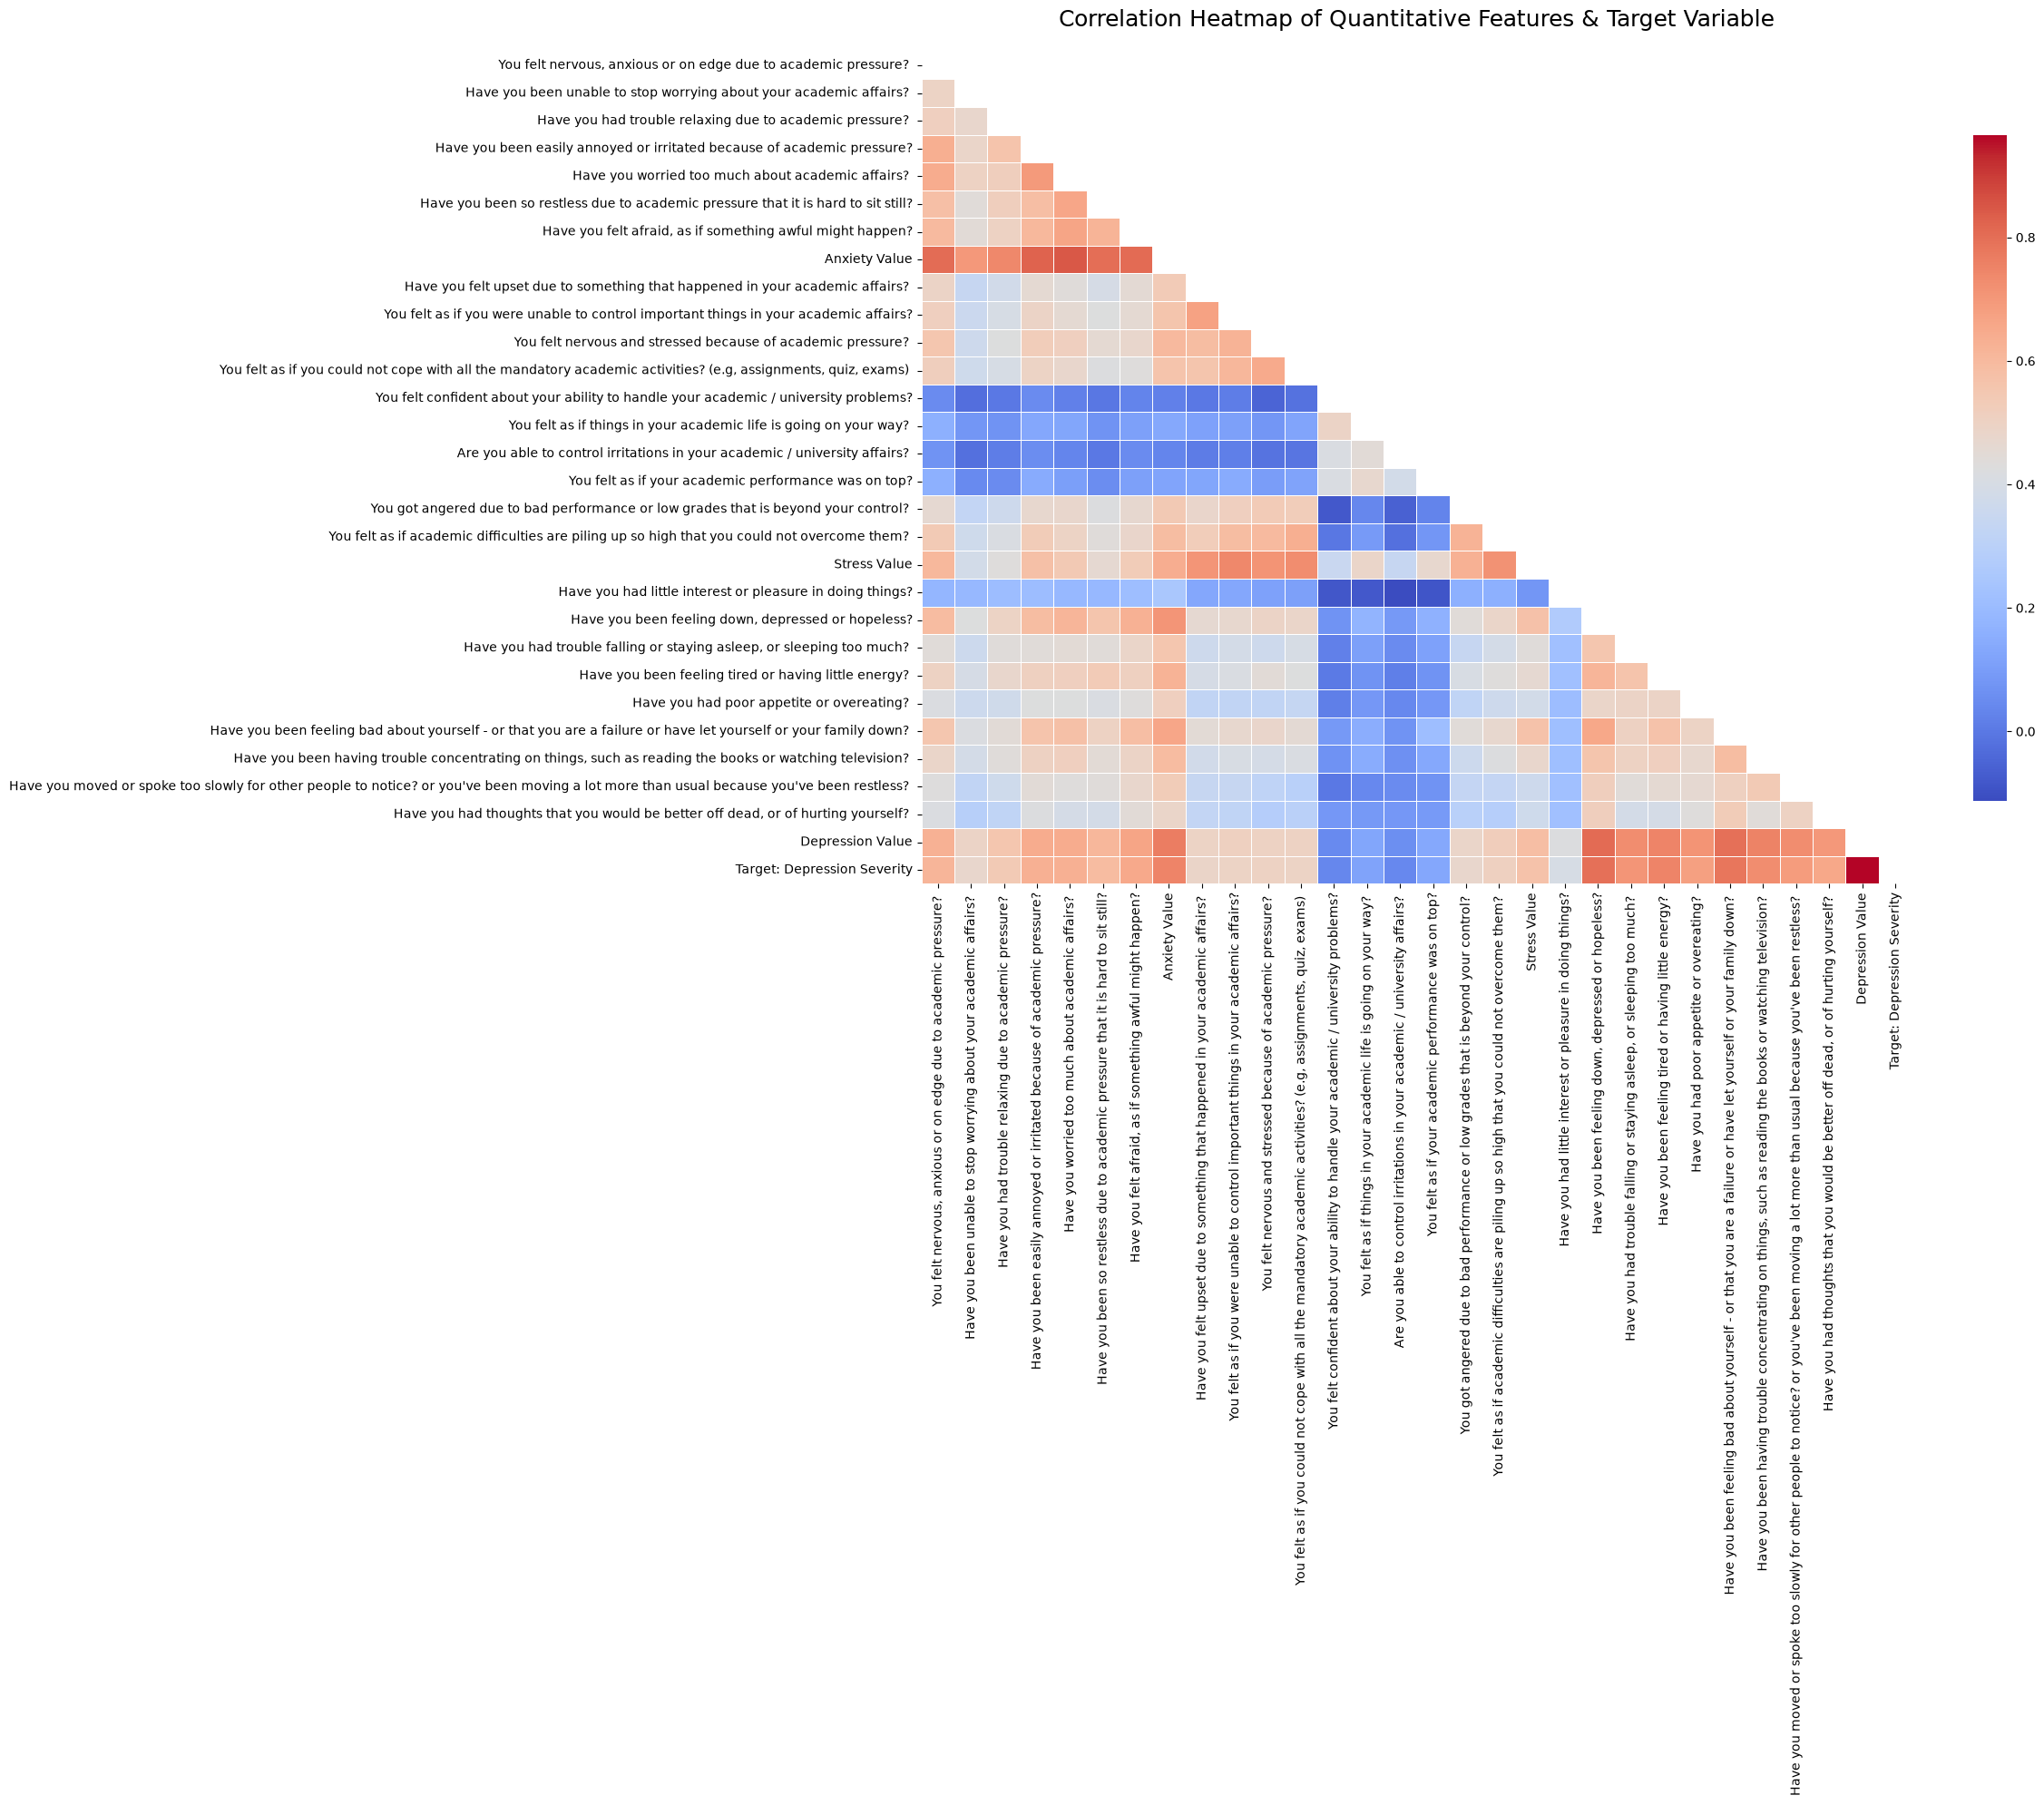

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# temporary numeric mapping for the target variable to include in the heatmap
label_mapping = {
    'No Depression': 0, 'Minimal Depression': 1, 'Mild Depression': 2,
    'Moderate Depression': 3, 'Moderately Severe Depression': 4, 'Severe Depression': 5
}

# Filter only quantitative (numerical) columns 
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

# Add encoded target variable to the numeric dataframe
numeric_df['Target: Depression Severity'] = df['Depression Label'].map(label_mapping)

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# mask to hide the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# shorten the labels 
clean_labels = []
for col in numeric_df.columns:
    if "how often " in col:
        clean_name = col.split("how often ")[-1].capitalize()
        clean_labels.append(clean_name)
    else:
        clean_labels.append(col)

# figure size
plt.figure(figsize=(24, 20))

# Plot heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            xticklabels=clean_labels, yticklabels=clean_labels, 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Quantitative Features & Target Variable', fontsize=18, pad=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Imbalanced Dataset

* The dataset is imbalanced. The target variable (`Depression Label`) does not have an equal distribution across its six classes. 

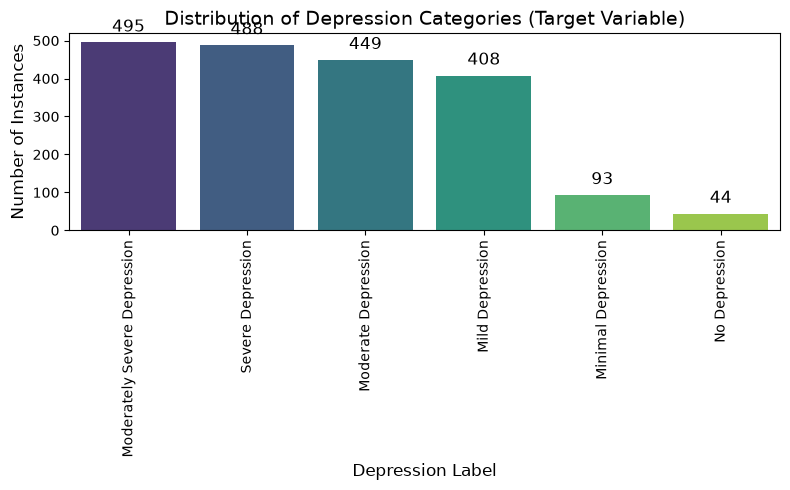


Exact counts for Imbalanced Dataset section:
Depression Label
Moderately Severe Depression    495
Severe Depression               488
Moderate Depression             449
Mild Depression                 408
Minimal Depression               93
No Depression                    44
Name: count, dtype: int64


In [29]:

# 1. Target Variable Distribution (To check for Imbalance)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Depression Label', palette='viridis', 
                   order=df['Depression Label'].value_counts().index)

# Print top bars numbers 
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Depression Categories (Target Variable)', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)

# Rotate x-axis labels vertically 
plt.xticks(rotation=90) 

plt.tight_layout()
plt.show()

# Print the exact counts 
print("\nExact counts for Imbalanced Dataset section:")
print(df['Depression Label'].value_counts())

### Exploratory Data Analysis (EDA) - Important Relationships

To extract important relationships from the data, several exploratory visualizations were generated:

1. **Depression Severity vs. Stress Levels:** 

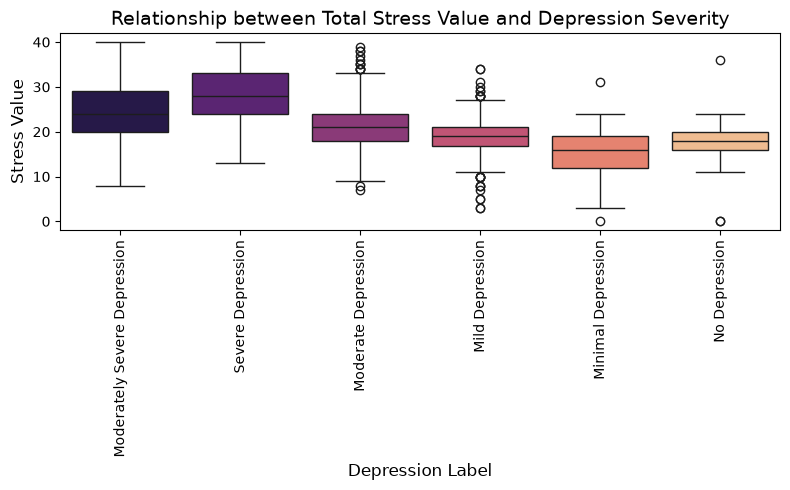

In [30]:

# EDA Relationship 1: Stress Value vs. Depression Label

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Depression Label', y='Stress Value', palette='magma', 
            order=df['Depression Label'].value_counts().index)
plt.title('Relationship between Total Stress Value and Depression Severity', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Stress Value', fontsize=12)

# Rotate x-axis labels vertically 
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


2. **Depression Distribution by Gender:** 

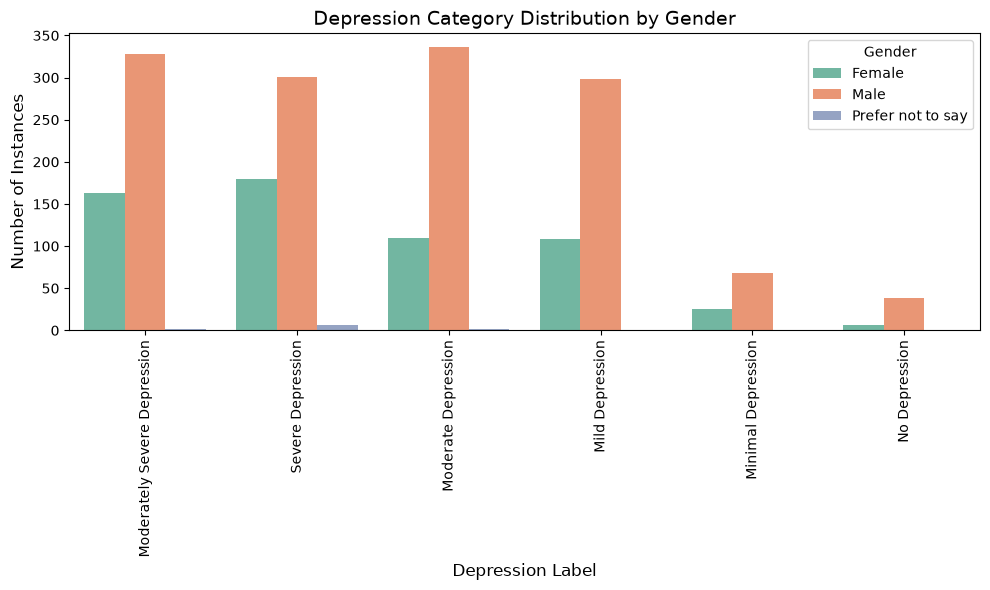

In [31]:

# EDA Relationship 2: Depression Label grouped by Gender

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Depression Label', hue='2. Gender', palette='Set2', 
              order=df['Depression Label'].value_counts().index)
plt.title('Depression Category Distribution by Gender', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)

# Rotate x-axis labels vertically
plt.xticks(rotation=90)

plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## 3. Dataset Pre-processing

### Problem 1: Null / Missing Values
* **Solution Applied (Row Deletion):** 

### Problem 2: Categorical Values
* **Solution Applied (One-Hot & Label Encoding):** 

### Problem 3: Feature Scaling (post-split)
* **Solution Applied (Min-Max Normalization)** 

In [ ]:
import warnings
warnings.filterwarnings('ignore')

print(f"Original Dataset Shape: {df.shape}")
print(f"Missing values before processing: {df.isnull().sum().sum()}")


# Handling Missing Values (Delete)

df_cleaned = df.dropna().copy()
print(f"Dataset Shape after dropping nulls: {df_cleaned.shape}")


# Handling Categorical Values (Ordinal Mapping)

label_mapping = {
    'No Depression': 0, 'Minimal Depression': 1, 'Mild Depression': 2,
    'Moderate Depression': 3, 'Moderately Severe Depression': 4, 'Severe Depression': 5
}
df_cleaned['Depression Label'] = df_cleaned['Depression Label'].map(label_mapping)



# Remove Data Leakage 

# find the 9 depression questions by taking the 9 columns before 'Depression Value'
dep_val_idx = df_cleaned.columns.get_loc('Depression Value')
depression_question_cols = df_cleaned.columns[dep_val_idx - 9 : dep_val_idx].tolist()

# Combine with the Depression Value column
leakage_cols = depression_question_cols + ['Depression Value']

print(f"\nDropping {len(leakage_cols)} leakage columns...")
df_no_leakage = df_cleaned.drop(columns=leakage_cols)


# 4. One-Hot Encode
categorical_cols = df_no_leakage.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_no_leakage, columns=categorical_cols, drop_first=True)

# Separate X (inputs) and y (target)
X = df_encoded.drop(columns=['Depression Label'])
y = df_encoded['Depression Label']

print(f"New input feature count for true predictive modeling: {X.shape[1]}")

Original Dataset Shape: (1977, 37)
Missing values before processing: 6
Dataset Shape after dropping nulls: (1971, 37)

Dropping 10 leakage columns...
New input feature count for true predictive modeling: 40


## 4. Dataset Splitting


* **Split Ratio:**  (80% - train) and (20% - test) 
* **Stratified Splitting Strategy** 

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


# Stratified 80/20 Split 

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y 
)


# Min-Max Scaling (Prevents Leakage)

scaler = MinMaxScaler()

# Fit ONLY on training data, then transform both
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

# Prepare a fully scaled version for Unsupervised K-Means later
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Output Summary
print("--- Dataset Splitting & Scaling Summary ---")
print(f"Total instances: {X.shape[0]}")
print(f"Training Set (80%): {X_train.shape[0]} instances (Scaled)")
print(f"Testing Set (20%): {X_test.shape[0]} instances (Scaled)")

# Verify stratification worked on the Training Set
print("\nClass distribution in Training Set:")
print(y_train.value_counts(normalize=True).round(3) * 100)

--- Dataset Splitting & Scaling Summary ---
Total instances: 1971
Training Set (80%): 1576 instances (Scaled)
Testing Set (20%): 395 instances (Scaled)

Class distribution in Training Set:
Depression Label
4    25.0
5    24.7
3    22.7
2    20.6
1     4.7
0     2.2
Name: proportion, dtype: float64


## 5. Model Training & Testing

Using both supervised learning and unsupervised learning.

### 5.1 Supervised Learning (Classification)

1. **Logistic Regression** 
2. **Decision Tree Classifier** 
3. **Neural Network (Multi-Layer Perceptron)** 

### 5.2 Unsupervised Learning 
 
1. **K-Means Clustering** 
2. **Showcasing the Clusters (PCA)** 

Training Supervised Models...

--- Supervised Testing Set Accuracy ---
Logistic Regression Accuracy: 0.4987
Decision Tree Accuracy:       0.3797
Neural Network Accuracy:      0.4076

Applying K-Means Clustering...


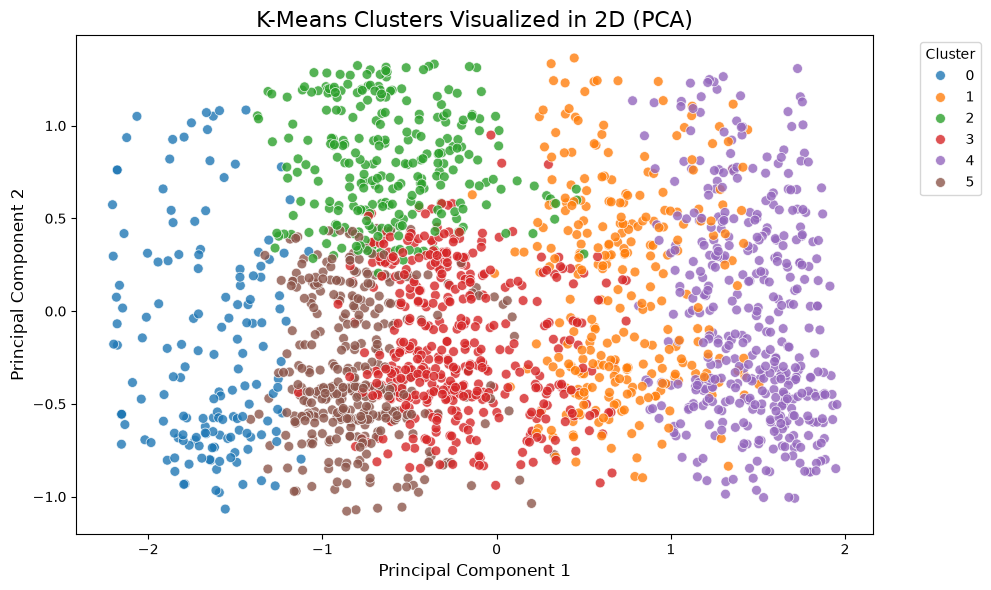

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# PART A: SUPERVISED LEARNING


# Initialize Models
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

# Train the Models on the Training Set
print("Training Supervised Models...")
log_reg_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)

# Test Models
log_reg_preds = log_reg_model.predict(X_test)
dt_preds = dt_model.predict(X_test)
nn_preds = nn_model.predict(X_test)

# Display Testing Accuracy
print("\n--- Supervised Testing Set Accuracy ---")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_reg_preds):.4f}")
print(f"Decision Tree Accuracy:       {accuracy_score(y_test, dt_preds):.4f}")
print(f"Neural Network Accuracy:      {accuracy_score(y_test, nn_preds):.4f}")





# PART B: UNSUPERVISED LEARNING (K-MEANS)


print("\nApplying K-Means Clustering...")

# Apply K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Dimension Reduced for Visualization (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['K-Means Cluster'] = cluster_labels

# Show Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='Principal Component 1', y='Principal Component 2', 
                hue='K-Means Cluster', palette='tab10', s=50, alpha=0.8)

plt.title('K-Means Clusters Visualized in 2D (PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Model Selection & Comparison Analysis




In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Generate Probabilities ( for AUC & ROC)
log_reg_probs = log_reg_model.predict_proba(X_test)
dt_probs = dt_model.predict_proba(X_test)
nn_probs = nn_model.predict_proba(X_test)


# Calculate Precision, Recall, and AUC
models = ['Logistic Regression', 'Decision Tree', 'Neural Network']
accuracies = [accuracy_score(y_test, log_reg_preds), accuracy_score(y_test, dt_preds), accuracy_score(y_test, nn_preds)]

precisions = [
    precision_score(y_test, log_reg_preds, average='weighted', zero_division=0),
    precision_score(y_test, dt_preds, average='weighted', zero_division=0),
    precision_score(y_test, nn_preds, average='weighted', zero_division=0)
]

recalls = [
    recall_score(y_test, log_reg_preds, average='weighted'),
    recall_score(y_test, dt_preds, average='weighted'),
    recall_score(y_test, nn_preds, average='weighted')
]

# Binarize labels for Multi-class AUC calculation
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

auc_scores = [
    roc_auc_score(y_test_bin, log_reg_probs, multi_class='ovr', average='weighted'),
    roc_auc_score(y_test_bin, dt_probs, multi_class='ovr', average='weighted'),
    roc_auc_score(y_test_bin, nn_probs, multi_class='ovr', average='weighted')
]

# Print Scores
for i, model in enumerate(models):
    print(f"{model}:")
    print(f"  Accuracy:  {accuracies[i]:.4f}")
    print(f"  Precision: {precisions[i]:.4f}")
    print(f"  Recall:    {recalls[i]:.4f}")
    print(f"  AUC Score: {auc_scores[i]:.4f}\n")

Logistic Regression:
  Accuracy:  0.4987
  Precision: 0.4852
  Recall:    0.4987
  AUC Score: 0.7804

Decision Tree:
  Accuracy:  0.3797
  Precision: 0.3852
  Recall:    0.3797
  AUC Score: 0.6055

Neural Network:
  Accuracy:  0.4076
  Precision: 0.4128
  Recall:    0.4076
  AUC Score: 0.6955



### 6.1 Accuracy Comparison

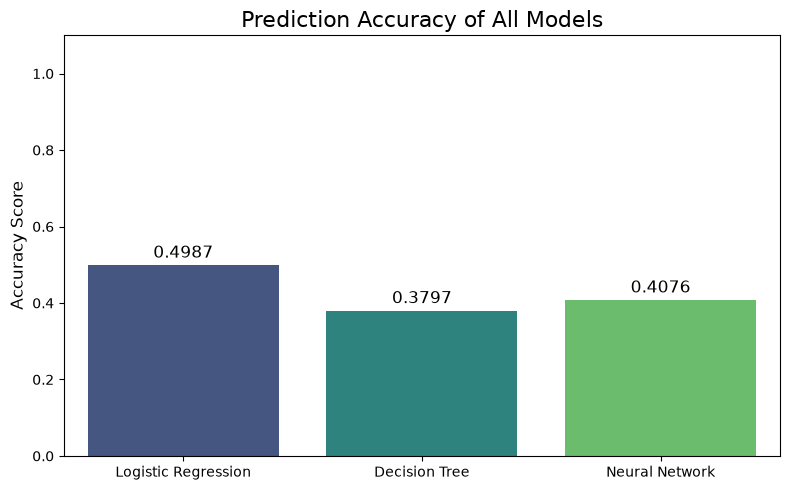

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Prediction Accuracy of All Models', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 Precision & Recall Comparison

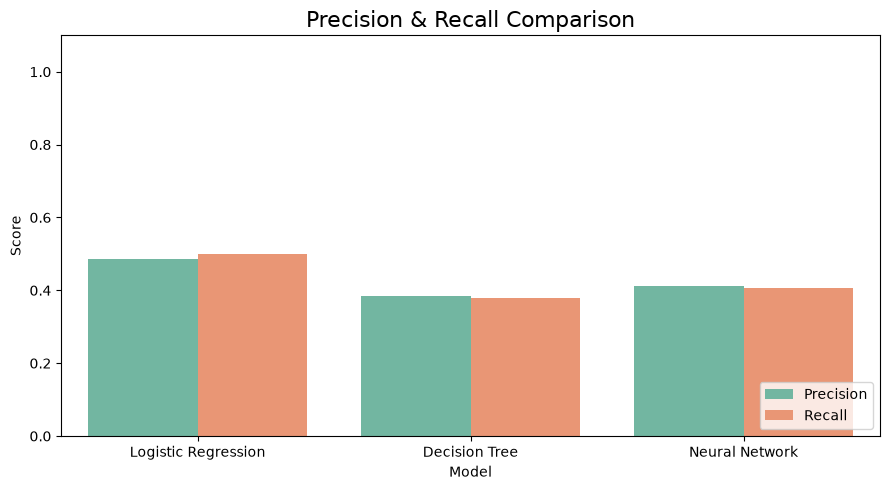

In [37]:
# Precision & Recall Bar Chart
metrics_df = pd.DataFrame({
    'Model': models * 2,
    'Score': precisions + recalls,
    'Metric': ['Precision']*3 + ['Recall']*3
})
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Precision & Recall Comparison', fontsize=16)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6.3 Confusion Matrices

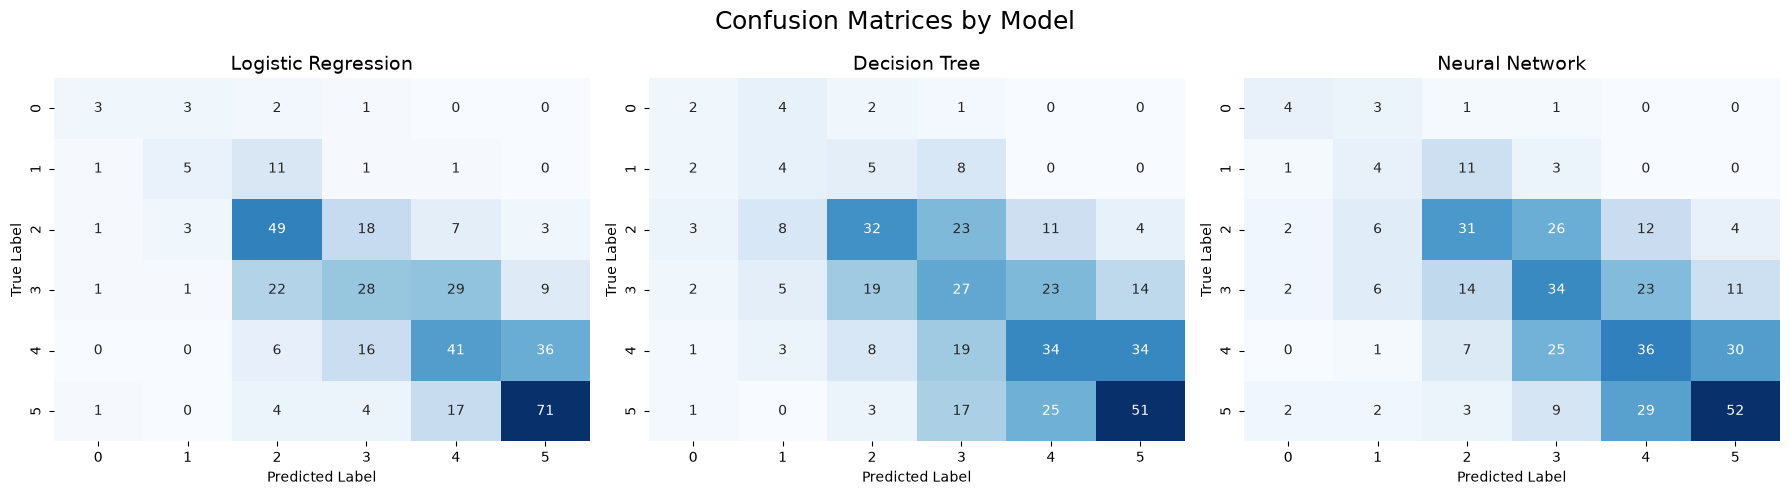

In [38]:
# Confusion Matrices (1x3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices by Model', fontsize=18)
cms = [confusion_matrix(y_test, log_reg_preds), confusion_matrix(y_test, dt_preds), confusion_matrix(y_test, nn_preds)]

for i, ax in enumerate(axes):
    sns.heatmap(cms[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(models[i], fontsize=14)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

### 6.4 ROC Curve & AUC Scores

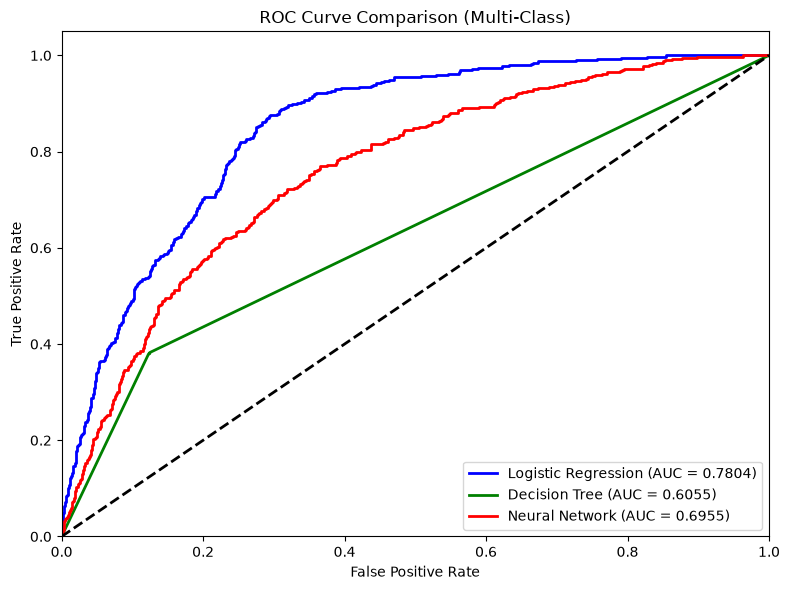

In [39]:
# ROC Curve
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
prob_list = [log_reg_probs, dt_probs, nn_probs]

for i, probs in enumerate(prob_list):
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{models[i]} (AUC = {auc_scores[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Multi-Class)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---

## 7. Model Comparison & Conclusion
| Model | Accuracy | Precision (Weighted) | Recall (Weighted) | AUC Score |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression** | **0.4987** | **0.4852** | **0.4987** | **0.7804** |
| **Neural Network (MLP)** | 0.4076 | 0.4128 | 0.4076 | 0.6955 |
| **Decision Tree** | 0.3797 | 0.3852 | 0.3797 | 0.6055 |

* **Logistic Regression** delivered the best performance, significantly outperforming the 16.6% random baseline across all metrics. The Decision Tree overfit the training data, while the Neural Network showed moderate generalization. Confusion matrices indicate errors were predominantly bounded within adjacent severity classes.

---

### Key Takeaways

* **Core Findings:** Academic stress and anxiety are reliable standalone predictors of depression severity. Unsupervised K-Means clustering ($K=6$) verified that students naturally segment into distinct risk profiles without predefined labels.
* **Data Leakage Resolution:** Dropping the 9 direct survey questions and the aggregate `Depression Value` eliminated artificial 100% memorization, establishing an authentic predictive benchmark.
* **Key Challenges Solved:** Handled target skew via **Stratified Splitting**, prevented scaling leakage by fitting `MinMaxScaler` strictly post-split, and structured high-cardinality survey inputs using **One-Hot Encoding** and **Ordinal Mapping**.